# Occupancy Networks for Synthetic Peptides
Implementation based on: https://github.com/autonomousvision/occupancy_networks

**Paper:** "Occupancy Networks: 3D Reconstruction in Function Space" (Mescheder et al., CVPR 2019)

**Architecture:**
- **Encoder**: Image encoder (ResNet18 by default) for visual feature extraction
- **Decoder**: Fully-connected ResNet blocks with latent code conditioning
- **Latent Code**: Optional latent variables for shape diversity
- **Training**: Query-based occupancy prediction with optional latent inference

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '2'

import sys
import importlib
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import distributions as dist
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import json
from pathlib import Path

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.4.1
CUDA available: True
CUDA version: 12.0
GPU: NVIDIA GeForce RTX 2080 Ti


## Module Integration: Import occupancy_networks Code

In [2]:
# ============================================================================
# OCCUPANCY NETWORK IMPLEMENTATION (imported from occupancy_networks module)
# ============================================================================

project_root = Path.cwd()
onet_root = project_root / 'occupancy_networks'
if str(onet_root) not in sys.path:
    sys.path.insert(0, str(onet_root))

from im2mesh.onet.models import OccupancyNetwork
from im2mesh.onet.models.decoder import (
    Decoder,
    DecoderBatchNorm,
    DecoderCBatchNorm,
    DecoderCBatchNorm2,
    DecoderCBatchNormNoResnet,
)
from im2mesh.encoder.pointnet import ResnetPointnet

import synthetic_peptides_dataset
importlib.reload(synthetic_peptides_dataset)
from synthetic_peptides_dataset import SyntheticPeptidesDataset

print("✓ ONet implementation imported from occupancy_networks folder")


✓ ONet implementation imported from occupancy_networks folder


## Configuration and Reproducibility

In [3]:
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

config_dict = {
    'run_name': 'onet_peptides_pointcloud_conditional_1000',
    'train_data_path': './data/synthetic_peptides_split/train',
    'val_data_path': './data/synthetic_peptides_split/val',
    'test_data_path': './data/synthetic_peptides_split/test',

    # Dataset
    'grid_size': 64,
    'num_query_points': 6000,
    'occupancy_threshold': 0.01,
    'train_num_files': 1000,
    'val_num_files': 213,
    'pointcloud_n': 3000,        # fixed-size input point cloud for encoder

    # Pointcloud conditional ONet (z_dim=0, c from PointNet encoder)
    'z_dim': 0,
    'c_dim': 128,
    'encoder_hidden_dim': 128,
    'decoder_hidden_size': 256,

    # Training
    'batch_size': 32,
    'learning_rate': 2e-4,
    'epochs': 2000,
    'save_every': 10,
    'val_interval': 10,
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"Run name: {config_dict['run_name']}")
print(f"Config: {json.dumps(config_dict, indent=2)}")


Device: cuda
Run name: onet_peptides_pointcloud_conditional_1000
Config: {
  "run_name": "onet_peptides_pointcloud_conditional_1000",
  "train_data_path": "./data/synthetic_peptides_split/train",
  "val_data_path": "./data/synthetic_peptides_split/val",
  "test_data_path": "./data/synthetic_peptides_split/test",
  "grid_size": 64,
  "num_query_points": 6000,
  "occupancy_threshold": 0.01,
  "train_num_files": 1000,
  "val_num_files": 213,
  "pointcloud_n": 3000,
  "z_dim": 0,
  "c_dim": 128,
  "encoder_hidden_dim": 128,
  "decoder_hidden_size": 256,
  "batch_size": 32,
  "learning_rate": 0.0002,
  "epochs": 2000,
  "save_every": 10,
  "val_interval": 10
}


## Dataset for Peptides

In [4]:
from scipy.spatial import cKDTree
def points_to_voxels(points, grid_size=32):
    voxel_grid = np.zeros((grid_size, grid_size, grid_size), dtype=np.float32)
    points_norm = points + 0.5
    indices = (points_norm * (grid_size - 1)).astype(int)
    indices = np.clip(indices, 0, grid_size - 1)
    voxel_grid[indices[:, 0], indices[:, 1], indices[:, 2]] = 1.0
    return voxel_grid


class PeptideDataset(Dataset):
    def __init__(
        self,
        data_path='./data/synthetic_peptides',
        grid_size=64,
        num_query_points=2000,
        num_files=None,
        structure_types=None,
        occupancy_threshold=0.02,
        target_num_points=None,
        pointcloud_n=300,
        seed=None,
    ):
        self.grid_size = grid_size
        self.num_query_points = num_query_points
        self.occupancy_threshold = occupancy_threshold
        self.pointcloud_n = pointcloud_n

        self.base_dataset = SyntheticPeptidesDataset(
            data_path=data_path,
            structure_types=structure_types,
            num_files=num_files,
            target_num_points=target_num_points,
            normalize=True,
            return_peptide_ids=True,
            seed=seed,
        )

        self.files = self.base_dataset.files
        self.file_types = self.base_dataset.file_types

        print(
            f"Peptide dataset ready: {len(self.files)} files, "
            f"grid={grid_size}^3, query_points={num_query_points}, "
            f"threshold={occupancy_threshold}, pointcloud_n={pointcloud_n}"
        )

    def __len__(self):
        return len(self.base_dataset)

    def get_centroid_points(self, idx):
        sample = self.base_dataset[idx]
        centroid_points = sample['points'].cpu().numpy()
        peptide_ids = sample['peptide_ids'].cpu().numpy()
        mask = sample['mask'].cpu().numpy().astype(bool)
        return centroid_points[mask], peptide_ids[mask]

    def __getitem__(self, idx):
        try:
            centroid_points, _ = self.get_centroid_points(idx)
            if len(centroid_points) == 0:
                raise ValueError('No peptide centroids found')

            # --- Input point cloud (fixed size for batching) ---
            n = len(centroid_points)
            if n >= self.pointcloud_n:
                chosen_pc = np.random.choice(n, self.pointcloud_n, replace=False)
            else:
                chosen_pc = np.random.choice(n, self.pointcloud_n, replace=True)
            pointcloud = torch.tensor(centroid_points[chosen_pc], dtype=torch.float32)

            oversample_factor = 10
            # --- Query points with occupancy labels ---
            n_half = self.num_query_points // 2

            tree = cKDTree(centroid_points)
            candidates = (np.random.rand(self.num_query_points * oversample_factor, 3) - 0.5).astype(np.float32)
            min_dists, _ = tree.query(candidates, k=1, workers=1)
            occ_candidates = min_dists < 0.01

            pos_idx = np.where(occ_candidates)[0]
            neg_idx = np.where(~occ_candidates)[0]

            pos_chosen = np.random.choice(pos_idx, n_half, replace=len(pos_idx) < n_half)
            neg_chosen = np.random.choice(neg_idx, n_half, replace=len(neg_idx) < n_half)

            chosen = np.concatenate([pos_chosen, neg_chosen])
            np.random.shuffle(chosen)

            query_points = torch.tensor(candidates[chosen], dtype=torch.float32)
            occupancy = torch.tensor(occ_candidates[chosen], dtype=torch.float32)

            return {
                'pointcloud': pointcloud,   # (pointcloud_n, 3) — input to encoder
                'query_points': query_points,
                'occupancy': occupancy,
                'idx': idx
            }

        except Exception as e:
            print(f"Error loading {self.files[idx]}: {e}")
            return {
                'pointcloud': torch.zeros(self.pointcloud_n, 3),
                'query_points': torch.rand(self.num_query_points, 3) - 0.5,
                'occupancy': torch.zeros(self.num_query_points),
                'idx': idx
            }


train_dataset = PeptideDataset(
    data_path=config_dict['train_data_path'],
    grid_size=config_dict['grid_size'],
    num_query_points=config_dict['num_query_points'],
    num_files=config_dict['train_num_files'],
    occupancy_threshold=config_dict['occupancy_threshold'],
    structure_types=None,
    pointcloud_n=config_dict['pointcloud_n'],
)

val_dataset = PeptideDataset(
    data_path=config_dict['val_data_path'],
    grid_size=config_dict['grid_size'],
    num_query_points=config_dict['num_query_points'],
    num_files=config_dict['val_num_files'],
    occupancy_threshold=config_dict['occupancy_threshold'],
    structure_types=None,
    pointcloud_n=config_dict['pointcloud_n'],
)

train_loader = DataLoader(train_dataset, batch_size=config_dict['batch_size'], shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=config_dict['batch_size'], shuffle=False, num_workers=4)

print(f"Train loader: {len(train_loader)} batches")
print(f"Val loader: {len(val_loader)} batches")


Loading centroid dataset from: ./data/synthetic_peptides_split/train
Structure types: lamellar_sheets, micelles, nanofibers, nanotubes, random_aggregates
Selected files per structure:
  lamellar_sheets: 71/700
  micelles: 71/700
  nanofibers: 71/700
  nanotubes: 71/700
  random_aggregates: 714/7000
Dataset ready: 998 files, target_points=None, normalize=True
Peptide dataset ready: 998 files, grid=64^3, query_points=6000, threshold=0.01, pointcloud_n=3000
Loading centroid dataset from: ./data/synthetic_peptides_split/val
Structure types: lamellar_sheets, micelles, nanofibers, nanotubes, random_aggregates
Selected files per structure:
  lamellar_sheets: 15/150
  micelles: 15/150
  nanofibers: 15/150
  nanotubes: 15/150
  random_aggregates: 152/1500
Dataset ready: 212 files, target_points=None, normalize=True
Peptide dataset ready: 212 files, grid=64^3, query_points=6000, threshold=0.01, pointcloud_n=3000
Train loader: 32 batches
Val loader: 7 batches


In [5]:
# Visualize Occupancy Labeling
sample_idx = 1
sample = train_dataset[sample_idx]

query_points_np = sample['query_points'].numpy()
occupancy_np = sample['occupancy'].numpy()

# Separate occupied vs unoccupied points
occupied_mask = occupancy_np > 0.5
unoccupied_mask = occupancy_np < 0.5

occupied_points = query_points_np[occupied_mask]
unoccupied_points = query_points_np[unoccupied_mask]

print(f"Sample {sample_idx} occupancy distribution:")
print(f"  Occupied points (peptides=1): {occupied_mask.sum()} points")
print(f"  Unoccupied points (empty=0): {unoccupied_mask.sum()} points")

# Create 3D visualization with occupancy points
fig = go.Figure()

# Add occupied points (blue - peptides)
if len(occupied_points) > 0:
    fig.add_trace(go.Scatter3d(
        x=occupied_points[:, 0],
        y=occupied_points[:, 1],
        z=occupied_points[:, 2],
        mode='markers',
        name='Occupied (peptides=1)',
        marker=dict(size=4, color='blue', opacity=0.8)
    ))

# Add unoccupied points (gray - empty space)
if len(unoccupied_points) > 0:
    fig.add_trace(go.Scatter3d(
        x=unoccupied_points[:, 0],
        y=unoccupied_points[:, 1],
        z=unoccupied_points[:, 2],
        mode='markers',
        name='Unoccupied (empty=0)',
        marker=dict(size=2, color='red', opacity=0.3)
    ))

fig.update_layout(
    title=f'Occupancy Visualization - Sample {sample_idx}',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        aspectmode='data',
    ),
    width=900,
    height=700,
    hovermode='closest'
)
fig.show()

print(f"\n✓ Occupancy visualization complete")
print(f"✓ Blue points = actual peptide centroids (occupancy=1)")
print(f"✓ Gray points = random empty space (occupancy=0)")

Sample 1 occupancy distribution:
  Occupied points (peptides=1): 3000 points
  Unoccupied points (empty=0): 3000 points



✓ Occupancy visualization complete
✓ Blue points = actual peptide centroids (occupancy=1)
✓ Gray points = random empty space (occupancy=0)


In [6]:
print(f"\n✓ Blue points = actual peptide centroid locations (occupied = 1)")
print(f"✓ Gray points = random empty space (occupied = 0)")


✓ Blue points = actual peptide centroid locations (occupied = 1)
✓ Gray points = random empty space (occupied = 0)


## Model Construction and Training Setup

In [7]:
from im2mesh.encoder.pointnet import ResnetPointnet

c_dim = config_dict['c_dim']

# PointNet encoder: point cloud -> c
encoder = ResnetPointnet(
    c_dim=c_dim,
    dim=3,
    hidden_dim=config_dict['encoder_hidden_dim'],
)

# CBatchNorm decoder: conditioned on c, no z
decoder = DecoderCBatchNorm(
    dim=3,
    z_dim=0,
    c_dim=c_dim,
    hidden_size=config_dict['decoder_hidden_size'],
    leaky=False,
)

# Prior over empty z
p0_z = dist.Normal(
    torch.zeros(0, device=device),
    torch.ones(0, device=device),
)

model = OccupancyNetwork(
    decoder=decoder,
    encoder=encoder,
    encoder_latent=None,   # no latent inference
    p0_z=p0_z,
    device=device,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=config_dict['learning_rate'])

total_params = sum(p.numel() for p in model.parameters())
encoder_params = sum(p.numel() for p in encoder.parameters())
decoder_params = sum(p.numel() for p in decoder.parameters())

print("\n=== TRAINING SETUP ===")
print(f"Run name: {config_dict['run_name']}")
print(f"Total parameters: {total_params:,}")
print(f"  Encoder (PointNet): {encoder_params:,}")
print(f"  Decoder (CBatchNorm): {decoder_params:,}")
print(f"Device: {device}")
print(f"Batch size: {config_dict['batch_size']}")
print(f"Learning rate: {config_dict['learning_rate']}")



=== TRAINING SETUP ===
Run name: onet_peptides_pointcloud_conditional_1000
Total parameters: 1,814,145
  Encoder (PointNet): 428,416
  Decoder (CBatchNorm): 1,385,729
Device: cuda
Batch size: 32
Learning rate: 0.0002


## Checkpoint Management

## Training Loop

In [8]:
checkpoint_dir = Path('checkpoints') / config_dict['run_name']
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = checkpoint_dir / 'latest.pth'
best_checkpoint_path = checkpoint_dir / 'best.pth'
log_path = checkpoint_dir / 'training_log.json'

# Training history
start_epoch = 0
train_losses = []
train_rec_losses = []
train_kl_losses = []
val_losses = []
val_rec_losses = []
val_kl_losses = []
best_loss = float('inf')

# Try to resume from checkpoint
if checkpoint_path.exists():
    print(f"\nLoading checkpoint from {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    try:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        train_losses = checkpoint.get('train_losses', [])
        train_rec_losses = checkpoint.get('train_rec_losses', [])
        train_kl_losses = checkpoint.get('train_kl_losses', [])
        val_losses = checkpoint.get('val_losses', [])
        val_rec_losses = checkpoint.get('val_rec_losses', [])
        val_kl_losses = checkpoint.get('val_kl_losses', [])
        best_loss = checkpoint.get('best_loss', float('inf'))
        print(f"Resumed from epoch {start_epoch}")
    except RuntimeError as e:
        print(f"Checkpoint incompatible with current model, starting fresh: {e}")
else:
    print("Starting fresh training...")

print(f"Checkpoint dir: {checkpoint_dir}")

def compute_onet_loss(model, pointcloud, query, occ_gt, device):
    # Encode point cloud -> c (no latent z)
    c = model.encode_inputs(pointcloud)

    # z is empty since z_dim=0
    batch_size = query.size(0)
    z = torch.empty(batch_size, 0, device=device)

    logits = model.decode(query, z, c).logits
    loss = F.binary_cross_entropy_with_logits(logits, occ_gt, reduction='mean')

    probs = torch.sigmoid(logits)
    return loss, probs


try:
    for epoch in range(start_epoch, config_dict['epochs']):
        model.train()
        epoch_loss = 0.0

        for batch_idx, batch in enumerate(train_loader):
            pointcloud = batch['pointcloud'].to(device)
            query = batch['query_points'].to(device)
            occ_gt = batch['occupancy'].to(device)

            optimizer.zero_grad()
            loss, probs = compute_onet_loss(model, pointcloud, query, occ_gt, device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        val_avg_loss = None
        if epoch % config_dict['val_interval'] == 0:
            model.eval()
            val_loss_sum = 0.0
            with torch.no_grad():
                for batch in val_loader:
                    pointcloud = batch['pointcloud'].to(device)
                    query = batch['query_points'].to(device)
                    occ_gt = batch['occupancy'].to(device)
                    val_loss, _ = compute_onet_loss(model, pointcloud, query, occ_gt, device)
                    val_loss_sum += val_loss.item()

            val_avg_loss = val_loss_sum / len(val_loader)
            val_losses.append(val_avg_loss)

            if val_avg_loss < best_loss:
                best_loss = val_avg_loss
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'train_losses': train_losses,
                    'val_losses': val_losses,
                    'best_loss': best_loss,
                    'config': config_dict,
                }, best_checkpoint_path)

        if epoch % config_dict['val_interval'] == 0:
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.6f} | Val Loss: {val_avg_loss:.6f}")
        else:
            print(f"Epoch {epoch:3d} | Loss: {avg_loss:.6f}")

        if (epoch + 1) % config_dict['save_every'] == 0 or epoch == config_dict['epochs'] - 1:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_losses': train_losses,
                'val_losses': val_losses,
                'best_loss': best_loss,
                'config': config_dict,
            }, checkpoint_path)

            with open(log_path, 'w') as f:
                json.dump({
                    'epoch': epoch,
                    'train_losses': train_losses,
                    'val_losses': val_losses,
                    'best_loss': best_loss,
                    'config': config_dict,
                }, f, indent=2)

    print(f"\n✓ Training complete at epoch {epoch}")

except KeyboardInterrupt:
    print(f"\n⚠ Training interrupted at epoch {epoch}")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'best_loss': best_loss,
        'config': config_dict,
    }, checkpoint_path)
    print("Checkpoint saved")



Loading checkpoint from checkpoints/onet_peptides_pointcloud_conditional_1000/latest.pth...
Resumed from epoch 50
Checkpoint dir: checkpoints/onet_peptides_pointcloud_conditional_1000


/tmp/ipykernel_1998236/1459522570.py:21: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Epoch  50 | Loss: 0.266632 | Val Loss: 0.276093
Epoch  51 | Loss: 0.258915
Epoch  52 | Loss: 0.255218
Epoch  53 | Loss: 0.252176
Epoch  54 | Loss: 0.249051
Epoch  55 | Loss: 0.246576
Epoch  56 | Loss: 0.243656
Epoch  57 | Loss: 0.242952
Epoch  58 | Loss: 0.239541
Epoch  59 | Loss: 0.237816
Epoch  60 | Loss: 0.237599 | Val Loss: 0.266265
Epoch  61 | Loss: 0.236714
Epoch  62 | Loss: 0.236032
Epoch  63 | Loss: 0.234531
Epoch  64 | Loss: 0.233517
Epoch  65 | Loss: 0.230488
Epoch  66 | Loss: 0.229946
Epoch  67 | Loss: 0.228397
Epoch  68 | Loss: 0.229370
Epoch  69 | Loss: 0.229062
Epoch  70 | Loss: 0.226343 | Val Loss: 0.270174
Epoch  71 | Loss: 0.228082
Epoch  72 | Loss: 0.224496
Epoch  73 | Loss: 0.226748
Epoch  74 | Loss: 0.223739
Epoch  75 | Loss: 0.219877
Epoch  76 | Loss: 0.220586
Epoch  77 | Loss: 0.217408
Epoch  78 | Loss: 0.219815
Epoch  79 | Loss: 0.219900
Epoch  80 | Loss: 0.217575 | Val Loss: 0.274986
Epoch  81 | Loss: 0.216506
Epoch  82 | Loss: 0.214286
Epoch  83 | Loss: 0.21531

## Training Curves Visualization

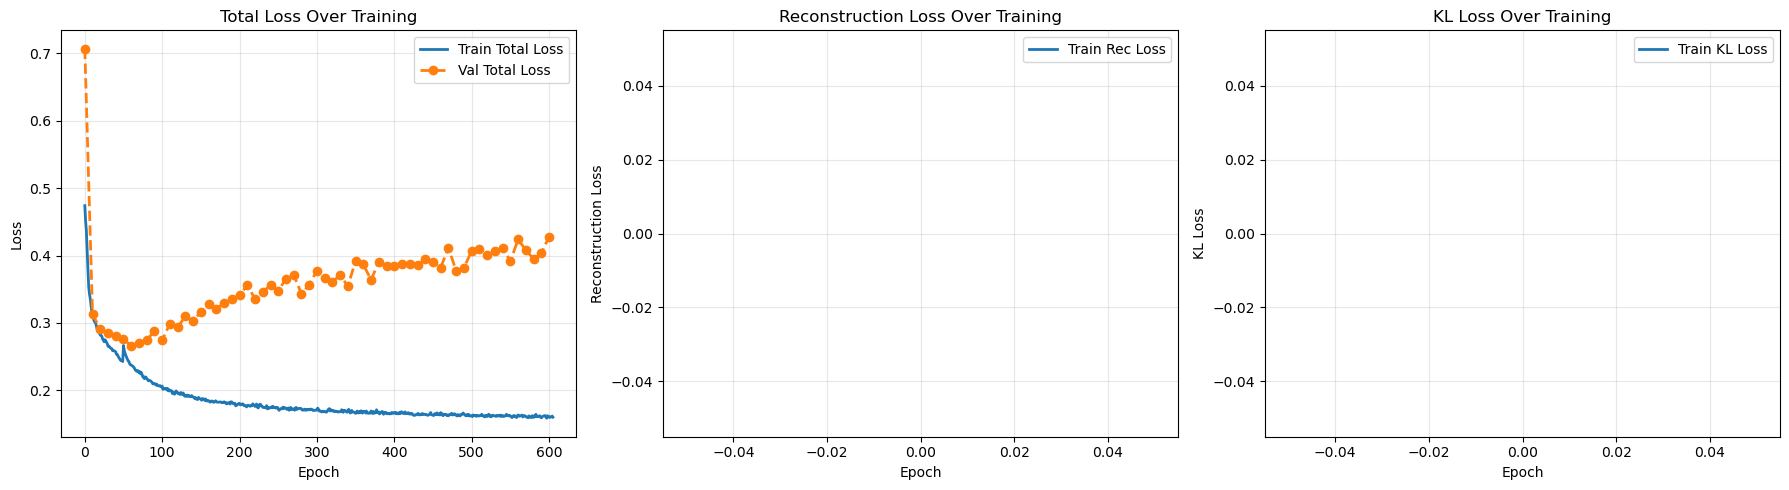


=== TRAINING SUMMARY ===
Final train total loss: 0.160429


IndexError: list index out of range

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot total loss
axes[0].plot(train_losses, label='Train Total Loss', linewidth=2)
if val_losses:
    val_epochs = list(range(0, len(train_losses), config_dict['val_interval']))[:len(val_losses)]
    axes[0].plot(val_epochs, val_losses, '--', label='Val Total Loss', linewidth=2, marker='o')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Total Loss Over Training')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot reconstruction loss
axes[1].plot(train_rec_losses, label='Train Rec Loss', linewidth=2)
if val_rec_losses:
    val_epochs = list(range(0, len(train_rec_losses), config_dict['val_interval']))[:len(val_rec_losses)]
    axes[1].plot(val_epochs, val_rec_losses, '--', label='Val Rec Loss', linewidth=2, marker='o')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss Over Training')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Plot KL loss
axes[2].plot(train_kl_losses, label='Train KL Loss', linewidth=2)
if val_kl_losses:
    val_epochs = list(range(0, len(train_kl_losses), config_dict['val_interval']))[:len(val_kl_losses)]
    axes[2].plot(val_epochs, val_kl_losses, '--', label='Val KL Loss', linewidth=2, marker='o')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Loss')
axes[2].set_title('KL Loss Over Training')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\n=== TRAINING SUMMARY ===")
print(f"Final train total loss: {train_losses[-1]:.6f}")
print(f"Final train rec loss: {train_rec_losses[-1]:.6f}")
print(f"Final train KL loss: {train_kl_losses[-1]:.6f}")
if val_losses:
    print(f"Final val total loss: {val_losses[-1]:.6f}")
if val_rec_losses:
    print(f"Final val rec loss: {val_rec_losses[-1]:.6f}")
if val_kl_losses:
    print(f"Final val KL loss: {val_kl_losses[-1]:.6f}")
print(f"Best val loss: {best_loss:.6f}")

In [10]:
## Reconstruction Visualization - Ground Truth vs Prediction

model.eval()
with torch.no_grad():
    sample = train_dataset[2]
    pointcloud = sample['pointcloud'].unsqueeze(0).to(device)
    query_points = sample['query_points'].unsqueeze(0).to(device)
    occ_gt = sample['occupancy'].unsqueeze(0).to(device)

    c = model.encode_inputs(pointcloud)
    z = torch.empty(1, 0, device=device)
    logits = model.decode(query_points, z, c).logits
    occ_pred = torch.sigmoid(logits)

occ_gt_np = occ_gt.squeeze().cpu().numpy()
occ_pred_np = occ_pred.squeeze().cpu().numpy()
query_points_np = query_points.squeeze().cpu().numpy()

# Use adaptive threshold based on quantiles
gt_threshold = np.quantile(occ_gt_np, 0.5)
pred_threshold = np.quantile(occ_pred_np, 0.5)

gt_mask = occ_gt_np > gt_threshold
pred_mask = occ_pred_np > pred_threshold

print(f"GT threshold: {gt_threshold:.4f}, GT points: {gt_mask.sum()}")
print(f"Pred threshold: {pred_threshold:.4f}, Pred points: {pred_mask.sum()}")

# Ground Truth Plot
fig1 = go.Figure(data=[go.Scatter3d(x=query_points_np[gt_mask, 0], y=query_points_np[gt_mask, 1],
                                     z=query_points_np[gt_mask, 2], mode='markers',
                                     marker=dict(size=2, color='blue'))])
fig1.update_layout(title='Ground Truth', scene_aspectmode='data', width=700, height=600)
fig1.show()

# Reconstruction Plot
fig2 = go.Figure(data=[go.Scatter3d(x=query_points_np[pred_mask, 0], y=query_points_np[pred_mask, 1],
                                     z=query_points_np[pred_mask, 2], mode='markers',
                                     marker=dict(size=2, color='red'))])
fig2.update_layout(title='Reconstruction', scene_aspectmode='data', width=700, height=600)
fig2.show()


GT threshold: 0.5000, GT points: 3000
Pred threshold: 0.8765, Pred points: 2999
